# Explaratory Data Analysis for Price Predicting Regression Model
**This notebook originally belonged to @AlvinWjy25 on github**

> **Dataset Source**: PostgreSQL table `public.fct_ebay_listings` (generated via dbt transformation pipeline, run `dbt run` and `dbt test` to get started).  

> **Target Variables**: `price` (Final) and `price_per_volume` (ablation test)

> **Domain**: Light Novel & Manga E-commerce Listings (eBay)
---
## 1. Objective:
- **Data Understanding**: Examine feature distributions, listing condition categories, and volume attributes extracted from listing titles.
- **Risk & Outlier Filtering**: Quantify listing risk scores (`text_risk_score`, `total_risk_score`) to isolate reliable listings from noisy/scam data.
- **Ablation & Experimentation**: Compare regression baselines for predicting listing price vs price-per-volume.
- **Error Diagnosis**: Perform residual analysis on top prediction errors to guide future feature engineering.

[!TIP]: This notebook is designed with Outline, feel free to navigate around with headings!

In [424]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

load_dotenv('../config/.env')  # reuse .env to prevent leak
os.getcwd()

'c:\\Users\\Alvin\\Music\\project_1\\notebook'

---
## 2. Environment Setup & Data Loading
### Notes & Business Logic:
- Loads database credentials from `config/.env`.
- Pulls processed feature marts directly from `fct_ebay_listings`.
- **Validation Check**: Run `dbt test` prior to analysis to guarantee schema integrity.
- Read [1.3 Project Setup Guide: eBay Light Novel Price Intelligence Documentation](#https://app.notion.com/p/eBay-Light-Novel-Price-Intelligence-Documentation-2-0-3bf16382ebe58040abeaeed49986dd13?source=copy_link#3bf16382ebe580cc878bc301b9a7228b) to create and configure your DB.

In [425]:
# Koneksi ke Postgres, baca langsung dari tabel marts hasil dbt
DB_USER = os.getenv("DB_USER", "alvin")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "price_intelligence")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

#Schema: 'public' fact table from mart
df_raw = pd.read_sql("SELECT * FROM public.fct_ebay_listings", engine)

print(f"Total baris: {len(df_raw)}")
df_raw.head()

Total baris: 2525


,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence
0,v1|115965603147|0,Spy Classroom Volumes 1-3 Light Novel Set New ...,56,10,USD,Brand New,US,True,False,False,0,False,False,False,False,False,40.5,13.5000,1.0,3.0,3.0,0,0,Low Risk,medium
1,v1|116204521440|0,"Spy Classroom, Vol. 7 (light novel): A Glint i...",79,15,USD,Brand New,US,False,False,False,0,False,False,False,False,False,17.2,17.2000,7.0,NaN,1.0,0,0,Low Risk,high
2,v1|116263745717|0,"Gimai Seikatsu, Days with My Step Sister Light...",80,13,USD,Brand New,MY,True,False,False,0,False,False,False,False,False,149.9,18.7375,1.0,8.0,8.0,70,0,High Risk,medium
3,v1|116267961169|0,The Eminence in Shadow 1-6 Novel English New H...,57,10,USD,Brand New,US,False,False,False,0,False,False,False,False,False,108.0,108.0000,NaN,NaN,1.0,0,0,Low Risk,low
4,v1|116268231670|0,"Bofuri: I Don't Want to Get Hurt, so I'll Max ...",79,17,USD,Brand New,US,False,False,False,0,False,False,False,False,False,17.2,17.2000,13.0,NaN,1.0,0,0,Low Risk,medium


In [426]:
df_raw['condition'].value_counts()

condition
Brand New           1340
Good                 390
Very Good            288
Like New             223
New                   94
Used                  71
Acceptable            58
Ungraded              32
Pre-Owned - Good       1
Name: count, dtype: int64

---
## 3. Dataframe Schema

Full description of each column in df_raw & df_price_model:

### **3.1 Target Variable**
| Column Name | Data Type | Description | Modeling Role |
| :--- | :--- | :--- | :--- |
| `price` | `float` | Listing price in USD | Target Variable (Primary) |
| `price_per_volume` | `float` | Calculated price divided by total volume count | Target Variable (Normalized) |
---
### **3.2 Identifiers & Metadata**
| Column Name | Data Type | Description | Modeling Role |
| :--- | :--- | :--- | :--- |
| `item_id` | `string` | Unique listing ID format (`v1\|listing_id\|index`) | Primary Key / Excluded from training |
| `title` | `string` | Raw listing title text from eBay | Metadata / Text Source |
| `seller_location` | `string` | 2-letter ISO country code of seller | Categorical Feature |
| `currency` | `string` | Listing currency (e.g., USD) | Metadata (Filter check) |

      [NOTE]: all of the product price is based on USD currency via eBay API ingestion by default.
---
### **3.3 Volume & Edition Extraction Features**
- These column is generated/extracted from `staging -> marts` in dbt run

| Column Name | Data Type | Description | Modeling Role |
| :--- | :--- | :--- | :--- |
| `volume_number` | `float` | Starting volume number parsed from title | Numerical Feature |
| `volume_number_end` | `float` | Ending volume number parsed for sets/bundles | Numerical Feature |
| `volume_count` | `float` | Total number of books included in the listing | Core Numerical Feature |
| `is_boxset` | `bool` | Flag indicating if title describes a full boxset | Binary Feature |
| `is_special_edition` | `bool` | Flag for limited/collector/special editions | Binary Feature |
| `boxset_side_story_edition_included` | `bool` | Flag if side story/extra content is included in set | Binary Feature |
| `standalone_side_story_edition` | `bool` | Flag for standalone side stories/spin-offs | Binary Feature |
| `title_length` | `int` | Character count of the title | Numerical Feature |
| `title_word_count` | `int` | Total word count of the title | Numerical Feature |
| `condition` | `string` | Item condition (`Brand New`, `Like New`, `Very Good`, `Good`, `New`, `Used`, `Acceptable`, `Ungraded`, `Pre-owned - Good`) | Categorical Feature |
---
### **3.4 Data Quality & Risk Indicators**
- These column is generated/extracted from `staging -> marts` in dbt run

| Column Name | Data Type | Description | Data Cleaning Role |
| :--- | :--- | :--- | :--- |
| `text_risk_score` | `int` | REGEXP based heuristic score flagging dubious text patterns | Data Filtering Threshold |
| `total_risk_score` | `int` | Combined risk score combining text & seller indicators | Data Filtering Threshold |
| `risk_category` | `string` | Risk tier (`Low Risk`, `Medium Risk`, `High Risk`) | Outlier / Scam Filtering |
| `volume_confidence` | `string` | Confidence grade of volume parsing (`high`, `medium`, `low`) | Quality Weighting |

# **A. Gaining Insight about the DataFrame**

In [427]:
df_raw.describe()

,title_length,title_word_count,total_bonus_count,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score
count,2525.000000,2525.000000,2525.000000,2525.000000,2525.000000,2112.000000,784.000000,2525.000000,2525.000000,2525.000000
mean,70.241188,11.739010,0.287921,78.547881,28.205644,4.318182,16.095663,5.642376,14.998020,2.560396
std,11.941486,2.329359,0.601003,109.978324,62.265922,5.104506,8.517979,8.391296,28.727123,6.947335
min,15.000000,3.000000,0.000000,2.490000,0.302093,0.000000,1.000000,1.000000,0.000000,0.000000
25%,64.000000,10.000000,0.000000,13.500000,10.518519,1.000000,11.000000,1.000000,0.000000,0.000000
50%,76.000000,12.000000,0.000000,23.410000,14.990000,2.000000,13.000000,1.000000,0.000000,0.000000
75%,79.000000,13.000000,0.000000,125.000000,22.290000,6.000000,26.000000,8.000000,0.000000,0.000000
max,80.000000,19.000000,4.000000,1999.000000,1999.000000,29.000000,45.000000,45.000000,70.000000,30.000000


## A.1 Inspecting Missing Value

In [428]:
missing_summary = df_raw.isnull().sum().to_frame('missing_count')
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(df_raw) * 100).round(1)
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_%
volume_number_end,1741,69.0
volume_number,413,16.4
condition,28,1.1
item_id,0,0.0
title,0,0.0
currency,0,0.0
seller_location,0,0.0
title_word_count,0,0.0
title_length,0,0.0
is_special_edition,0,0.0


- Our data contains is dominated by 69% individual light novel volume.
- Arround 413 volume failed to be extracted due to missing `Vol.`, `Volumes`, `Part`, `Vol` during REGEXP detection in `staging -> mart` process

In [429]:
df_raw[df_raw['volume_number'].isnull()].head(3)

,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence
3,v1|116267961169|0,The Eminence in Shadow 1-6 Novel English New H...,57,10,USD,Brand New,US,False,False,False,0,False,False,False,False,False,108.00,108.00,NaN,NaN,1.0,0,0,Low Risk,low
7,v1|116798503714|0,Rascal Does Not Dream of Bunny Girl Senpai Ani...,69,11,USD,Brand New,JP,False,False,False,1,True,False,False,False,False,51.81,51.81,NaN,NaN,1.0,70,0,High Risk,low
11,v1|117234412006|0,The Eminence in Shadow Official Anime Art Book,46,8,USD,Very Good,JP,False,False,False,0,False,False,False,False,False,37.99,37.99,NaN,NaN,1.0,0,0,Low Risk,low


Based on the DBT logic:
- if a product have ambigous/non-standard volume number writing in the title, it will be flagged as 'low' in `volume_confidence` column. 
- if a product contain keyword of counterfeit / non-official in title/description, it will be flagged as 'High Risk' in `risk_category` column.

The filtered dataframe from low confidence & high risk category is `df_price_model`:

## A.2 Filtering High Risk and Low Confidence for Ambigous Volume Number and Non-official Item

In [430]:
print(f"risk_category distribution (all):{df_raw['risk_category'].value_counts()}")

df_price_model = df_raw[(df_raw['risk_category'] != 'High Risk') & (df_raw['volume_confidence'] != 'low')]
print(f"risk_category distribution (w/0 high risk & > low confidence): {df_price_model['risk_category'].value_counts()}")

risk_category distribution (all):risk_category
Low Risk     1984
High Risk     541
Name: count, dtype: int64
risk_category distribution (w/0 high risk & > low confidence): risk_category
Low Risk    1583
Name: count, dtype: int64


After filtering, our data is reduced from 2525 onto 1583. Unfortunately, its the direct consequence of inconsistent product title writing. 

Forcing a wider REGEXP volume number detection may result in data quality drop such as overestimating or underestimating the volume count which poison our model. 

`[Recommendation]`: Use NLP / LLM assisted volume number extraction in bigger scale

Let's do a sanity check first: 
`the result must be empty, always check if you refactor something`



In [431]:
display(df_price_model[df_price_model['volume_count'].isna()])
display(df_price_model[df_price_model['risk_category'] == 'High Risk'])

,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence


,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence


Now let's inspect special edition light novel using filtered df_raw (`df_price_model`):

In [432]:
df_price_model[df_price_model['is_special_edition'] == True].describe()

,title_length,title_word_count,total_bonus_count,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,5.000000,78.000000,78.0,78.000000
mean,75.846154,12.512821,0.948718,121.968846,105.845233,5.730769,21.400000,2.307692,0.0,0.384615
std,6.869993,1.726370,0.681813,136.277886,123.657290,4.679808,6.542171,5.245425,0.0,2.386274
min,53.000000,8.000000,0.000000,8.850000,8.850000,1.000000,12.000000,1.000000,0.0,0.000000
25%,75.000000,12.000000,1.000000,43.505000,31.162500,1.000000,17.000000,1.000000,0.0,0.000000
50%,79.000000,13.000000,1.000000,79.900000,74.910000,5.000000,26.000000,1.000000,0.0,0.000000
75%,80.000000,13.000000,1.000000,188.557500,187.530000,8.000000,26.000000,1.000000,0.0,0.000000
max,80.000000,17.000000,3.000000,999.000000,999.000000,17.000000,26.000000,26.000000,0.0,15.000000


## A.3 Data Figure & Challenge

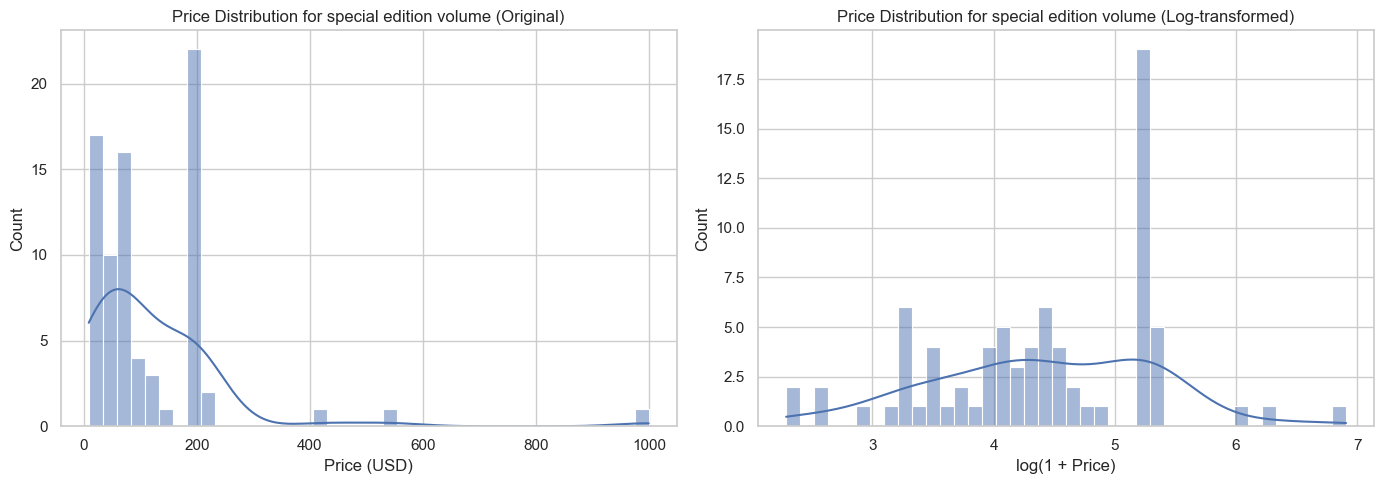

In [433]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model.loc[df_price_model["is_special_edition"] == True, "price"], bins = 40, kde = True, ax = axes[0])
axes[0].set_title('Price Distribution for special edition volume (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model.loc[df_price_model["is_special_edition"] == True, "price"]), bins = 40, kde = True, ax = axes[1])
axes[1].set_title('Price Distribution for special edition volume (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

After filtering, we only have 94 row of data where light novel has either special bonus, short stories, first printing, etc.

These special edition light novel presents many challanges:
1. **Data sparsity & high variance**: with only 94 observations, complex model or heavy gradient boosters without strong regularization will easily overfit to noise or rare outliers.

2. **Extreme Price skewness**: Shown by histogram & summary stats, price ranges from 8.85 to 1.999 dollars, with median of 80 and 75th percentile of 194.31. A single max value of almost 2k dollars creates massive swkewness which will disproportionately pull linear models or MSE-based loss function.

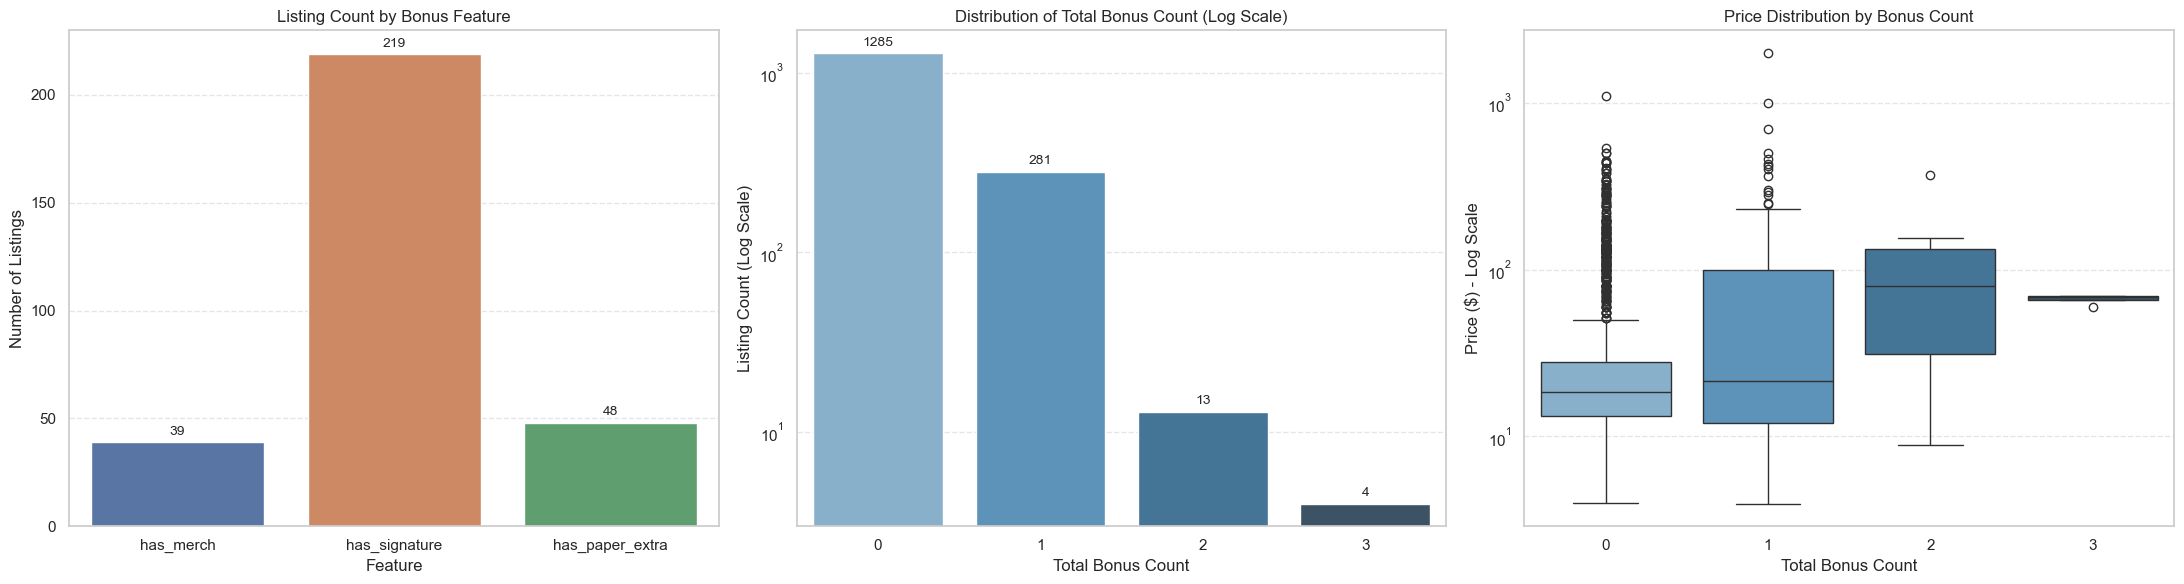

In [434]:
feature_counts = df_price_model[['has_merch', 'has_signature', 'has_paper_extra']].sum()

# Buat 1x3 grid (axes[2] diisi dengan boxplot harga per total_bonus_count)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Subplot 1: Feature Counts ---
sns.barplot(
    x=feature_counts.index, 
    y=feature_counts.values, 
    palette=['#4C72B0', '#DD8452', '#55A868'],
    ax=axes[0]
)

axes[0].set_title('Listing Count by Bonus Feature', fontsize=12)
axes[0].set_ylabel('Number of Listings')
axes[0].set_xlabel('Feature')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[0].patches:
    height = int(p.get_height())
    if height > 0:
        axes[0].annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=10, xytext=(0, 3),
            textcoords='offset points'
        )

# --- Subplot 2: Total Bonus Count (Log Scale) ---
sns.countplot(
    data=df_price_model, 
    x='total_bonus_count', 
    palette='Blues_d',
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Total Bonus Count (Log Scale)', fontsize=12)
axes[1].set_xlabel('Total Bonus Count')
axes[1].set_ylabel('Listing Count (Log Scale)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[1].patches:
    height = int(p.get_height())
    if height > 0:
        axes[1].annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=10, xytext=(0, 3),
            textcoords='offset points'
        )

# --- Subplot 3: Price vs Total Bonus Count ---
sns.boxplot(
    data=df_price_model, 
    x='total_bonus_count', 
    y='price', 
    palette='Blues_d',
    ax=axes[2]
)
axes[2].set_yscale('log')
axes[2].set_title('Price Distribution by Bonus Count', fontsize=12)
axes[2].set_xlabel('Total Bonus Count')
axes[2].set_ylabel('Price ($) - Log Scale')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [435]:
feature_counts

has_merch           39
has_signature      219
has_paper_extra     48
dtype: int64

[!NOTE]: `has_signature` is not considered to be `is_special_edition = True`.

Chart 1: Listing Count by Bonus Feature:
- `has_signature` dominates as a atribute bonus identified with a total of 213 listing.
- `has_paper_extra` followed behind with extra such as (obi, booklet, drama CD, clear file) identified at 47 listing
- `has merch` is the least containing (tapestry, acrylic standee, figure) with 39 listing available.

Chart 2: Distribution of Total Bonus Count (Log Scale)
- The majorit of light novel listings (1,272 data) doesn't have bonus attribute.
- There are around 274 listing with exactly 1 bonus, 2 bonus at 13 data and 3 bonus at 4 data. 

Chart 3: Observed Price Distribution by Bonus Count
- There is a increase of median price as bonus goes up (monotonic increase):
    - 0 Bonus: Median is arround $18-20
    - 1 Bonus: Median slightly increase but variance range significantly spread, depending of what's the bonus.
    - 2 Bonus: Median significantly increase to around ~$80-$100 dollars
    - 3 Bonus: Baseline price is stable at ~$70 dollars due to scarce light novel product containing 3 bonus at once in listings. 

More data is required to represent the true nature of 2 bonus (12 data) and 3 bonus (4 data) count actual price range.

In [436]:
for col in ['condition', 'seller_location']:
    print(f"{col}: {df_price_model[col].nunique()} unique category")
    print(df_price_model[col].value_counts())
    print()

condition: 7 unique category
condition
Brand New     743
Good          319
Very Good     224
Like New      132
New            82
Acceptable     42
Used           41
Name: count, dtype: int64

seller_location: 7 unique category
seller_location
US    1153
JP     268
MY      71
GB      45
AU      42
CA       3
DE       1
Name: count, dtype: int64



# B. Encoding & Feature Engineering

## B.1 FE: get_volume_tier for grouping large, medium, small volume signal

In [437]:
def get_volume_tier(count):
    if count == 1:
        return 1  # single_volume
    elif 2 <= count <= 5:
        return 2  # small_bundle
    elif 6 <= count <= 15:
        return 3  # medium_set
    else:
        return 4  # complete_large_set

df_price_model['volume_tier'] = df_price_model['volume_count'].apply(get_volume_tier)
df_price_model['volume_tier_encoded'] = df_price_model['volume_count'].apply(get_volume_tier)

location_counts = df_price_model['seller_location'].value_counts()
rare_locations = location_counts[location_counts < 30].index

df_price_model['seller_location_grouped'] = df_price_model['seller_location'].replace(
    rare_locations, 'Other'
)

## B.2 Encode: Condition - Ordinal

In [438]:
condition_map = {
    'Acceptable': 1,
    'Used': 3,
    'Good': 3,
    'Very Good': 4,
    'Like New': 5,
    'New': 6,
    'Brand New': 7,
    'unknown': 3  # Neutral fallback (middle ground)
}

df_price_model['condition_encoded'] = df_price_model['condition'].map(condition_map).fillna(3)

In [439]:
df_price_model = df_price_model.drop(columns = "condition")

Quick Sanity check:

In [440]:
df_price_model[df_price_model['volume_number'].isna()]

,item_id,title,title_length,title_word_count,currency,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence,volume_tier,volume_tier_encoded,seller_location_grouped,condition_encoded


# **C. Preparing Pipeline for Modelling**

## C.1 SMAPE Calculation

Why not MAPE? MAPE is often preferred over MAPE because it fixes the division-by-zero problem when actual values are zero, caps extreme percentage spikes, and treats over- and under-forecasting more evenly instead of unfairly penalizing high prediction.

In [441]:
import numpy as np

def calculate_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    # Avoid division by zero when both y_true and y_pred are 0
    epsilon = 1e-10
    denominator = np.where(denominator == 0, epsilon, denominator)
    
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

In [442]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils.class_weight import compute_sample_weight

## C.2 Define Features & Splitting

In [443]:
numeric_features = [
    'title_length', 
    'title_word_count', 
    'volume_count',
    'volume_tier_encoded',
    'condition_encoded',
    'total_bonus_count'
]

categorical_features = [
    'currency', 
    'seller_location'
]

boolean_features = [
    'is_boxset', 
    'is_special_edition', 
    'boxset_side_story_edition_included', 
    'standalone_side_story_edition',
    'is_first_print',
    'has_signature',
    'has_merch',
    'has_paper_extra',
]

def split_train_test(df):
    feature_cols = numeric_features + categorical_features + boolean_features
    target_col = 'price'

    X = df[feature_cols]
    y = df[target_col]

    df_meta = df[['item_id', 'title', 'is_special_edition', 'is_boxset']]

    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, df.index, test_size = 0.2, random_state = 42
    )

    print(f"Train: {len(X_train)}, Test: {len(X_test)}")

    return X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test

X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test = split_train_test(df_price_model)

Train: 1266, Test: 317


### C.2.1 Final Sanity Checks

In [444]:
X.isna().sum().sum()

np.int64(0)

In [445]:
(X_train['volume_count'] < 0).sum()
display(X_train[X_train['volume_count'] < 0].head(5))

,title_length,title_word_count,volume_count,volume_tier_encoded,condition_encoded,total_bonus_count,currency,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,is_first_print,has_signature,has_merch,has_paper_extra


In [446]:
X_train.head(5)

,title_length,title_word_count,volume_count,volume_tier_encoded,condition_encoded,total_bonus_count,currency,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,is_first_print,has_signature,has_merch,has_paper_extra
1703,50,8,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
361,80,14,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
1939,50,11,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
2159,80,15,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
2306,68,12,1.0,1,7,0,USD,GB,False,False,False,False,False,False,False,False


Make sure no negative price are present:

In [447]:
np.sum(df_price_model[df_price_model['price'] < 0])

0

Make sure categorical feature is a string

In [448]:
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

# **D. Creating Modular Pipeline**

In [449]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output = False), categorical_features),
        ('bool', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), boolean_features)
    ], remainder = 'passthrough'
)

def change_model(model_reggressor, verbose:int):
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       
        inverse_func=np.expm1 
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', RobustScaler(with_centering=False)), 
        ('regressor', model)
    ])
    
    baseline_pipeline.fit(X_train, y_train)
    y_pred = baseline_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"R^2     : {r2:.3f}")
    print(f"MAE     : {mae:.2f}")
    print(f"RMSE    : {rmse:.2f}")
    print(f"MAPE    : {mape:.3f}")
    print(f"SMAPE   : {smape:.3f}")

    results = pd.DataFrame({
        'item_id': df_meta.loc[indices_test, 'item_id'],
        'title': df_meta.loc[indices_test, 'title'],
        'is_boxset': df_meta.loc[indices_test, 'is_boxset'],
        'is_special_edition': df_meta.loc[indices_test, 'is_special_edition'],
        'volume_count': X_test['volume_count'],
        'Actual': y_test.values,
        'Predicted': y_pred
    }, index=indices_test)

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    # display 10 biggest error
    import matplotlib.pyplot as plt

    if verbose == 1:
        display(results.sort_values(by='Abs_Error', ascending=False))
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
        axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                    [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
        axes[0].set_xlabel('Actual')
        axes[0].set_ylabel('Predicted')
        axes[0].set_title('Actual vs Predicted')

        # Plot 2: Residual Plot
        axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
        axes[1].axhline(y=0, color='r', linestyle='--')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Residual (Actual - Predicted)')
        axes[1].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

        # display(X_train.head(5))

    return baseline_pipeline

## **D.1 Ablation Test 1 - w/ Ambigous Price Per Volume & High Variance**

In [450]:
lrr = change_model(LinearRegression(), 0)

R^2     : 0.528
MAE     : 21.75
RMSE    : 48.67
MAPE    : 0.411
SMAPE   : 34.357


In [451]:
rfr = change_model(RandomForestRegressor(random_state = 42, n_jobs = -1 ), 0)

R^2     : 0.590
MAE     : 18.57
RMSE    : 45.36
MAPE    : 0.417
SMAPE   : 30.681


In [452]:
import warnings as warnings
warnings.filterwarnings("ignore")
lgbm = change_model(LGBMRegressor(random_state=42, objective='regression_l1', learning_rate=0.05, force_row_wise = True), 0)

[LightGBM] [Info] Total Bins 121
[LightGBM] [Info] Number of data points in the train set: 1266, number of used features: 16
[LightGBM] [Info] Start training from score 3.008894
R^2     : 0.589
MAE     : 18.23
RMSE    : 45.41
MAPE    : 0.362
SMAPE   : 29.296


R^2     : -0.239
MAE     : 23.50
RMSE    : 78.82
MAPE    : 0.587
SMAPE   : 30.488


,item_id,title,is_boxset,is_special_edition,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
2140,v1|398091542500|666373137432,Re:Zero Starting Life in Another World Vol.1-4...,True,False,43.0,12.99,1120.608521,-1107.618521,1107.618521,8526.701467
1418,v1|336548044455|0,Rascal Does Not Dream of Bunny Girl Senpai Vol...,False,False,1.0,419.99,68.480721,351.509279,351.509279,83.694678
861,v1|264758690998|566199342059,NEW LIGHT NOVEL Re: Zero kara Hajimeru Isekai ...,True,False,44.0,99.00,402.274750,-303.274750,303.274750,306.338131
56,v1|127722168206|428888417043,Konosuba God's Blessing on This Wonderful Worl...,False,False,26.0,248.00,24.557207,223.442793,223.442793,90.097900
1420,v1|336608217077|0,The Angel Next Door Spoils Me Rotten Vol.1-12+...,True,False,12.0,132.30,306.270630,-173.970630,173.970630,131.497075
...,...,...,...,...,...,...,...,...,...,...
1131,v1|298543963276|0,Ascendance of a Bookworm: Part 5 Volume 1 (Lig...,False,False,1.0,18.02,18.014378,0.005622,0.005622,0.031201
1091,v1|287500094960|0,Ascendance of a Bookworm: Part 4 Volume 8 (Lig...,False,False,1.0,18.02,18.014378,0.005622,0.005622,0.031201
1490,v1|357466358309|0,Re:Zero-Starting Life in Another World Volume ...,False,False,1.0,28.99,28.991112,-0.001112,0.001112,0.003835
1680,v1|364312258417|0,"Spy Classroom, Vol. 2 (light novel) Format: Pa...",False,False,1.0,13.32,13.320126,-0.000126,0.000126,0.000943


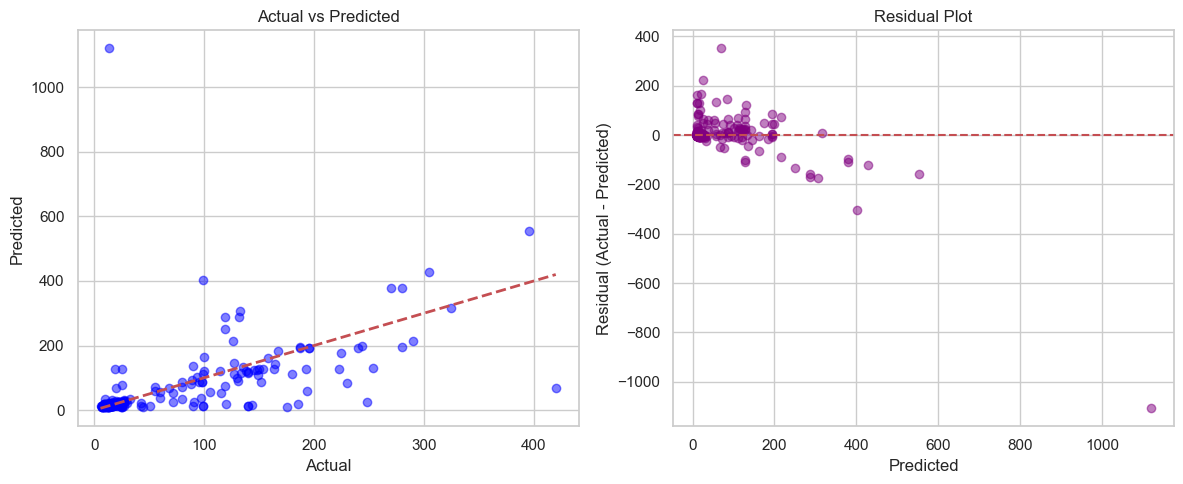

In [453]:
XGBr = change_model(XGBRegressor(random_state=42, tree_method = 'hist', objective='reg:absoluteerror', n_jobs = -1), 1)

In [454]:
y.describe()

count    1583.000000
mean       52.917574
std        98.023893
min         3.950000
25%        13.000000
50%        19.000000
75%        39.995000
max      1999.000000
Name: price, dtype: float64

Look at the first column that shows the item with the biggest percentage error:
2140	v1|398091542500|666373137432	Re:Zero Starting Life in Another World Vol.1-4...	True	False	43.0	12.99	1120.608521	-1107.618521	1107.618521

We are looking at 2 problem that cause Absolute Percentage Error that absolutely throw off our XGBr metrics with r^2 of negative value. This happen because there is a fundamental way of how each model handle (out of Distribution/Outlier Sensitivity):
1. Unit price misparsing issue
2. How model handles extreme outlier

---


**1. Unit Price Misparsing Issue:**

A price of $12.99 for 43 Volume is suspiciously too cheap. Searching the product through eBay manually:

![image_1](archive\aspect_unit_of_sale.png)

[NOTE]: The price may differ due to ingest.py ran in the past when price was 12.99/ea.

It turns out, eBay API was pulling the price as a total even though it's labeled as /ea, not in total. Seller must manually insert pricing type (total / each) in `aspect_unit_of_sale`, but most of it's column are missing or too generic such as 'Comic Book Lot', 'Single', 'Boxset':

Query for Diagnose:
```
select
	aspect_unit_of_sale,
	count(*)
from int_ebay_listing_risk_analysis 
group by aspect_unit_of_sale
```

![image_2](archive\eBay_Screenshot.png)

When the data treats 43 volumes of light novel set of $12.99/ea as total price of $12.99, the `price_per_volume` significantly drops to ~#0.30. Identifying suspiciously low price_per_volume regardless of the condition can be a useful way to identify mislabeled price listings, lets do an experiment:

To identify suspiciously low `price_per_volume`, we can do a threhold test and see our model performance

In [455]:
thresholds = [0, 2, 3, 4, 4.2, 4.4, 4.5, 4.6, 4.8, 5, 6, 8, 10, 9999]
results = []

def change_model2(model_reggressor, verbose:int):
    # Pipeline
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       
        inverse_func=np.expm1 
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', RobustScaler(with_centering=False)), 
        ('regressor', model)
    ])
    
    baseline_pipeline.fit(X_train, y_train)
    y_pred = baseline_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results = pd.DataFrame({
        'item_id': df_meta.loc[indices_test, 'item_id'],
        'title': df_meta.loc[indices_test, 'title'],
        'is_boxset': df_meta.loc[indices_test, 'is_boxset'],
        'is_special_edition': df_meta.loc[indices_test, 'is_special_edition'],
        'volume_count': X_test['volume_count'],
        'Actual': y_test.values,
        'Predicted': y_pred
    }, index=indices_test)

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    if verbose == 1:
        # display 10 biggest error
        display(results.sort_values(by='Abs_Error', ascending=False))

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
        axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                    [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
        axes[0].set_xlabel('Actual')
        axes[0].set_ylabel('Predicted')
        axes[0].set_title('Actual vs Predicted')

        # Plot 2: Residual Plot
        axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
        axes[1].axhline(y=0, color='r', linestyle='--')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Residual (Actual - Predicted)')
        axes[1].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

        # display(X_train.head(5))

    return r2, mae, smape, baseline_pipeline

for t in thresholds:
    # Masking
    mask = (df_price_model['volume_count'] >= 5) & (df_price_model['price_per_volume'] < t)
    df_test = df_price_model[~mask].copy()

    feature_cols = numeric_features + categorical_features + boolean_features
    target_col = 'price'

    X = df_test[feature_cols]
    y = df_test[target_col]

    df_meta = df_test[['item_id', 'title', 'is_special_edition', 'is_boxset']]

    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, df_test.index, test_size = 0.2, random_state = 42
    )

    xgb_r2, xgb_mae, xgb_smape, XGB2 = change_model2(XGBRegressor(random_state = 42, objective='reg:absoluteerror', tree_method = 'hist', n_jobs = -1), 0)
    lr_r2, lr_mae, lr_smape, LR2 = change_model2(LinearRegression(), 0)
    rfr_r2, rfr_mae, rfr_smape, RFR2 = change_model2(RandomForestRegressor(random_state=42, n_jobs=-1), 0)

    print(f"{t}: Train: {len(X_train)}, Test: {len(X_test)}")
    
    results.append({'threshold': t, 'xgb_r2': xgb_r2, 'rfr_r2': rfr_r2, 'lr_r2': lr_r2, 'xgb_mae': xgb_mae, 'rfr_mae': rfr_mae, 'lr_mae': lr_mae, 'xgb_smape': xgb_smape, 'rfr_smape': rfr_smape, 'lr_smape': lr_smape, 'n_excluded': mask.sum()})

results_df = pd.DataFrame(results)
results_df

0: Train: 1266, Test: 317
2: Train: 1260, Test: 316
3: Train: 1256, Test: 315
4: Train: 1254, Test: 314
4.2: Train: 1252, Test: 313
4.4: Train: 1252, Test: 313
4.5: Train: 1250, Test: 313
4.6: Train: 1249, Test: 313
4.8: Train: 1248, Test: 312
5: Train: 1247, Test: 312
6: Train: 1236, Test: 310
8: Train: 1215, Test: 304
10: Train: 1177, Test: 295
9999: Train: 1044, Test: 261


,threshold,xgb_r2,rfr_r2,lr_r2,xgb_mae,rfr_mae,lr_mae,xgb_smape,rfr_smape,lr_smape,n_excluded
0,0.0,-0.239036,0.589702,0.527580,23.499183,18.574663,21.751094,30.487743,30.680828,34.357123,0
1,2.0,0.722545,0.606304,0.543253,18.149814,20.803335,24.283982,29.700972,33.335601,36.129708,7
2,3.0,0.652568,0.591014,0.597653,16.479872,17.671290,18.800398,28.354069,29.776362,33.727486,12
3,4.0,0.585233,0.634345,0.563739,17.147265,18.265303,19.934457,27.565682,31.378277,34.666682,15
4,4.2,0.715841,0.731949,0.565681,12.410641,13.401809,15.444447,26.404961,29.947725,32.447675,18
5,4.4,0.715841,0.731949,0.565681,12.410641,13.401809,15.444447,26.404961,29.947725,32.447675,18
6,4.5,0.677653,0.670442,0.585128,13.454930,14.153322,16.364537,27.220702,29.073260,33.156625,20
7,4.6,0.731087,0.671695,0.638566,12.677771,14.777317,16.653073,24.721364,27.814578,31.229650,21
8,4.8,0.736500,0.757888,0.606886,12.705246,13.070051,16.722757,25.688764,28.803131,32.671306,23
9,5.0,0.788503,0.799416,0.622354,13.745052,14.128823,18.707206,25.993268,29.066174,33.379061,24


See how our model performance maintain it's stabiolity until $4.4 before detabilizing at $4.-~$10+? The data cut off after $4.4/volume reduces too much data noise that should be natural in E-Commerce. Remember that we use `price_per_volume` which is more sensitive measurement compared to `price`, so we have to be conservative with our decision. 

>We will use $4.4/volume as our valid cutoff.


**2. XGB Weakness(es)**:

Looking at LR:
R^2: 0.528, MAE: 21.75, RMSE: 48.67, SMAPE: 34.36

RFR:
R^2: 0.59, MAE: 18.57, RMSE: 45.36, SMAPE: 30.68

XGB: High Depth & Exact Split Point Trapping
R^2: -0.239, MAE:23.50, RMSE:78.82, SMAPE0: 30.49

**XGB agrresively** optimize gradient loss for every iteration of tree, looking at `volume_count` of 43 and splitting via `volume_count` >= 40 usually predict item on $200~$500+ dollars, meanwhile the actual price is 12.99.

A giant error residual of $1.107.62 with absolute Percentage Error of 1K+ causes sum squared error to be massively increased, making R^2 absolutely destroyed.

**RandomForest are safeguarded** by Feature & Sample Bagging because of Bagging Mechanism (Bootstrap Aggregating):
- Extract feature and sample is randomized for each tree
- Corrupted sample only included in a few sub-samples, so the effect doesn't snowball and smoothed out while averaging at the final step.

## D.2 Solving Ambigous Price Per Volume (No Outlier Data Cutoff yet - Separate issue)

In [456]:
def throw_ambigous_price(df_price_model):
    bulk_lot_mask = (df_price_model['volume_count'] >= 5) & (df_price_model['price_per_volume'] < 4.4) #cut off

    print(f"Total rows before exclusion: {len(df_price_model)}")
    print(f"Rows matching bulk-lot ambiguous pattern (volume_count >= 20, price_per_volume < 5): {bulk_lot_mask.sum()}")

    # Exclude them for this test
    df_price_model = df_price_model[~bulk_lot_mask].copy()

    print(f"Rows after exclusion: {len(df_price_model)}")
    return df_price_model

In [457]:
df_price_model = throw_ambigous_price(df_price_model)
X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test = split_train_test(df_price_model)

Total rows before exclusion: 1583
Rows matching bulk-lot ambiguous pattern (volume_count >= 20, price_per_volume < 5): 18
Rows after exclusion: 1565
Train: 1252, Test: 313


In [458]:
lr = change_model(LinearRegression(), 0)

R^2     : 0.566
MAE     : 15.44
RMSE    : 39.27
MAPE    : 0.382
SMAPE   : 32.448


In [459]:
rfr = change_model(RandomForestRegressor(random_state = 42, n_jobs = -1 ), 0)

R^2     : 0.732
MAE     : 13.40
RMSE    : 30.85
MAPE    : 0.385
SMAPE   : 29.948


In [460]:
import warnings as warnings
warnings.filterwarnings("ignore")
lgbm = change_model(LGBMRegressor(random_state=42, objective='regression_l1', learning_rate=0.05, force_row_wise = True), 0)

[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1252, number of used features: 16
[LightGBM] [Info] Start training from score 3.002460
R^2     : 0.737
MAE     : 11.82
RMSE    : 30.55
MAPE    : 0.271
SMAPE   : 26.070


R^2     : 0.716
MAE     : 12.41
RMSE    : 31.76
MAPE    : 0.274
SMAPE   : 26.405


,item_id,title,is_boxset,is_special_edition,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
2040,v1|396289360796|0,Overlord Japanese Light Novel set Vol.1-15 Wit...,True,False,15.0,405.65,130.105377,275.544623,275.544623,67.926691
1207,v1|307070837046|0,Classroom Of The Elite Year 2 Volume 1 2 3 4 4...,False,False,1.0,249.99,12.397240,237.592760,237.592760,95.040906
322,v1|166977017979|0,Classroom of the Elite (Light Novel) Vol. 2 [P...,False,False,1.0,185.23,23.000286,162.229714,162.229714,87.582850
1554,v1|358671132270|626818119318,Re:Zero Starting Life In Another World Light N...,True,False,28.0,229.99,383.418457,-153.428457,153.428457,66.710925
1170,v1|306661028154|606525292043,Re:Zero-Starting Life in Another World Light N...,True,False,26.0,119.29,238.101166,-118.811166,118.811166,99.598597
...,...,...,...,...,...,...,...,...,...,...
1126,v1|298510705356|0,Sword Art Online 17 (light novel): Alicization...,False,False,1.0,12.00,12.017175,-0.017175,0.017175,0.143123
1021,v1|284332067368|0,"RE: Zero -Starting Life in Another World-, Vol...",False,False,1.0,16.70,16.716028,-0.016028,0.016028,0.095977
1952,v1|388377496192|0,Ascendance of a Bookworm: Part 1 Volume 3 (Lig...,False,False,1.0,13.85,13.833996,0.016004,0.016004,0.115554
408,v1|177422655793|0,Too Many Losing Heroines! (Light Novel) Vol. 6,False,False,1.0,15.99,15.991009,-0.001009,0.001009,0.006309


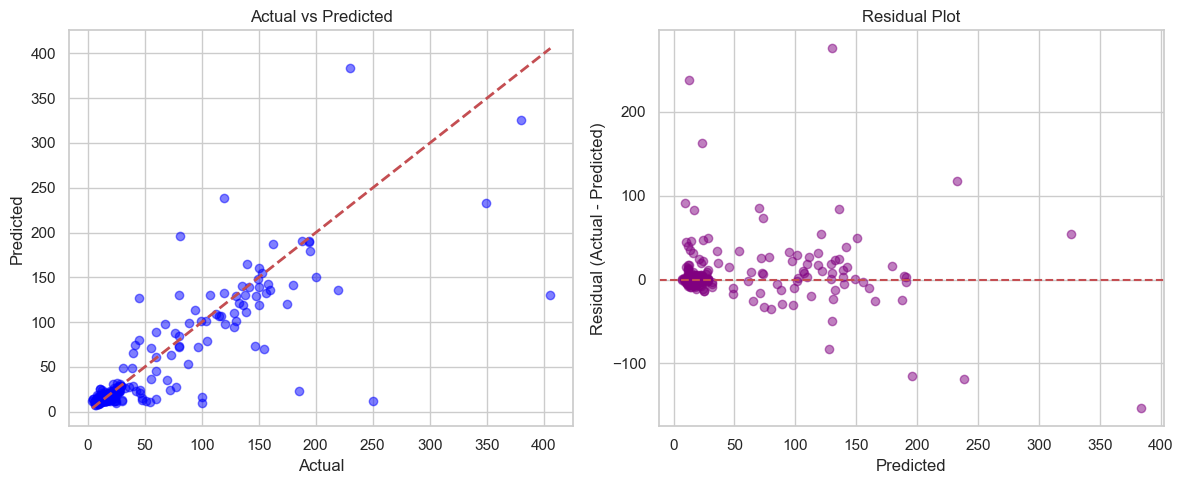

In [461]:
XGBr = change_model(XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs = -1), 1)

## D.3 Final Test - w/o Ambigous `price_per_volume` & High Variance

In [462]:
df_price_model[df_price_model['price'] > 1000]

,item_id,title,title_length,title_word_count,currency,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence,volume_tier,volume_tier_encoded,seller_location_grouped,condition_encoded
1877,v1|377253686891|0,Classroom of the Elite Complete English Light ...,73,13,USD,US,True,False,False,0,False,False,False,False,False,1099.99,35.483548,1.0,31.0,31.0,0,0,Low Risk,medium,4,4,US,5
1966,v1|388769692760|0,BGS9.6 Re:ZERO Starting Life in Another World ...,80,13,USD,JP,False,False,False,1,True,False,False,False,False,1999.00,1999.000000,1.0,NaN,1.0,0,0,Low Risk,medium,1,1,JP,4


In [ ]:
def throw_high_variance(df_price_model):
    bulk_lot_mask = (df_price_model['price'] > 1100) 
    print(f"Total rows before exclusion: {len(df_price_model)}")
    print(f"Rows with volume > 1000: {bulk_lot_mask.sum()}")

    # Exclude them for this test
    df_price_model = df_price_model[~bulk_lot_mask].copy()

    print(f"Rows after exclusion: {len(df_price_model)}")
    return df_price_model

In [464]:
df_price_model = throw_ambigous_price(df_price_model)
df_price_model = throw_high_variance(df_price_model)
X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test = split_train_test(df_price_model)

Total rows before exclusion: 1565
Rows matching bulk-lot ambiguous pattern (volume_count >= 20, price_per_volume < 5): 0
Rows after exclusion: 1565
Total rows before exclusion: 1565
Rows with volume > 1000: 1
Rows after exclusion: 1564
Train: 1251, Test: 313


In [465]:
lrr = change_model(LinearRegression(), 0)

R^2     : 0.626
MAE     : 15.52
RMSE    : 38.37
MAPE    : 0.386
SMAPE   : 32.771


In [466]:
rfr = change_model(RandomForestRegressor(random_state=42, n_jobs=-1), 0)

R^2     : 0.803
MAE     : 13.19
RMSE    : 27.83
MAPE    : 0.383
SMAPE   : 29.746


In [467]:
XGBr = change_model(XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs = -1), 0)

R^2     : 0.792
MAE     : 12.45
RMSE    : 28.59
MAPE    : 0.289
SMAPE   : 27.035


In [468]:
lgbm = change_model(LGBMRegressor(random_state=42, objective='regression_l1', learning_rate=0.05, force_row_wise = True), 0)

[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1251, number of used features: 16
[LightGBM] [Info] Start training from score 3.002708
R^2     : 0.822
MAE     : 11.19
RMSE    : 26.44
MAPE    : 0.268
SMAPE   : 25.669


# E. Final Model Inspection

In [470]:
lgbm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['title_length','title_word_count','volume_count',...,'has_signature', 'has_merch','has_paper_extra']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('bool', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pa

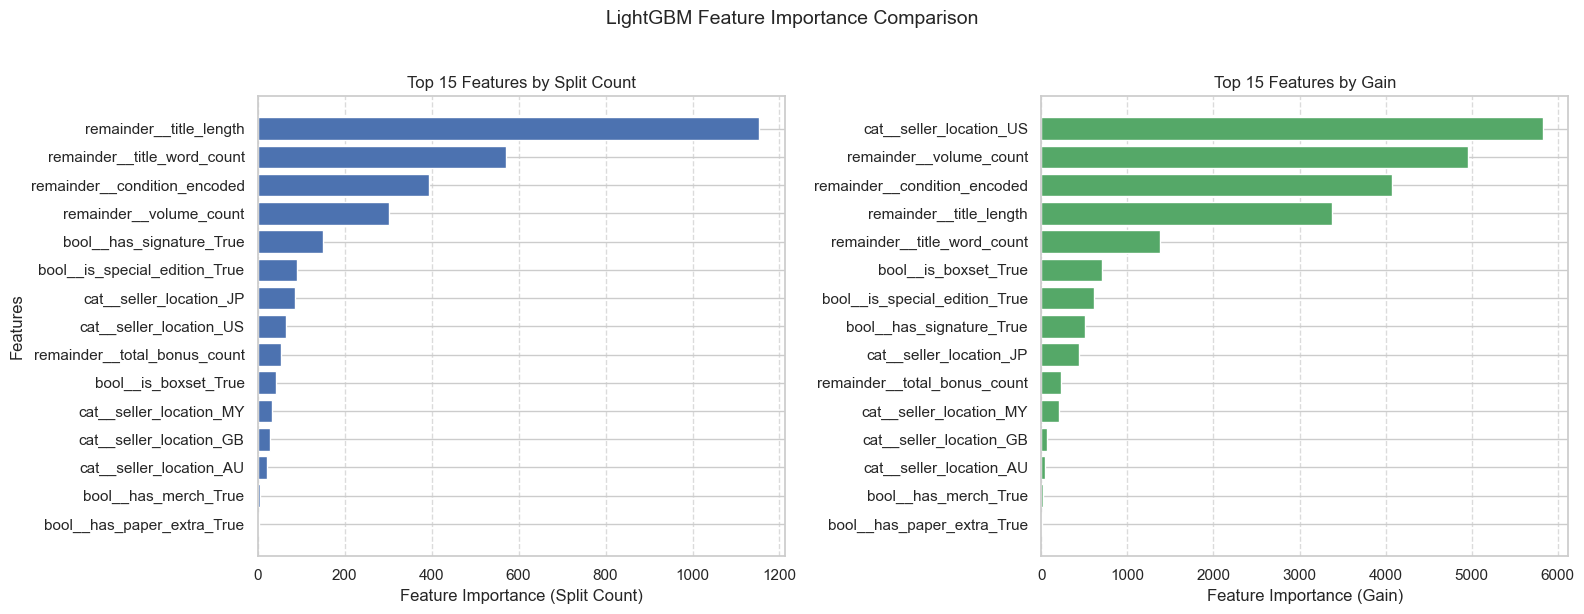

In [469]:
def plot_feature_importance(pipeline, top_n=15):
    # 1. Ekstrak objek ColumnTransformer & LightGBM dari Pipeline
    preprocessor = pipeline.named_steps['preprocessor']
    ttr_model = pipeline.named_steps['regressor'] # TransformedTargetRegressor
    lgbm_model = ttr_model.regressor_             # LGBMRegressor aktual

    # 2. Ambil nama fitur setelah OneHotEncoder & passthrough
    feature_names = preprocessor.get_feature_names_out()

    # 3. Buat DataFrame Feature Importance
    df_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': lgbm_model.feature_importances_
    }).sort_values('importance', ascending=False)

    df_gain = pd.DataFrame({
        'feature': feature_names,
        'importance':  lgbm_model.booster_.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Split Count (axes[0])
    axes[0].barh(df_imp['feature'][:top_n][::-1], df_imp['importance'][:top_n][::-1], color='#4C72B0')
    axes[0].set_xlabel('Feature Importance (Split Count)')
    axes[0].set_ylabel('Features')
    axes[0].set_title(f'Top {top_n} Features by Split Count')
    axes[0].grid(axis='x', linestyle='--', alpha=0.7)

    # Plot 2: Gain (axes[1])
    axes[1].barh(df_gain['feature'][:top_n][::-1], df_gain['importance'][:top_n][::-1], color='#55A868')
    axes[1].set_xlabel('Feature Importance (Gain)')
    # Hilangkan ylabel di plot kanan agar tidak menumpuk/redundan
    axes[1].set_title(f'Top {top_n} Features by Gain')
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)

    plt.suptitle('LightGBM Feature Importance Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return df_imp, df_gain, lgbm_model

# Cara panggil setelah running change_model:
df_imp, df_gain, lgbmr = plot_feature_importance(lgbm)
